Spot :  100
Volatility :  0.2
Skew :  0.3
Risk Free Rate :  0.01
Dividends :  0


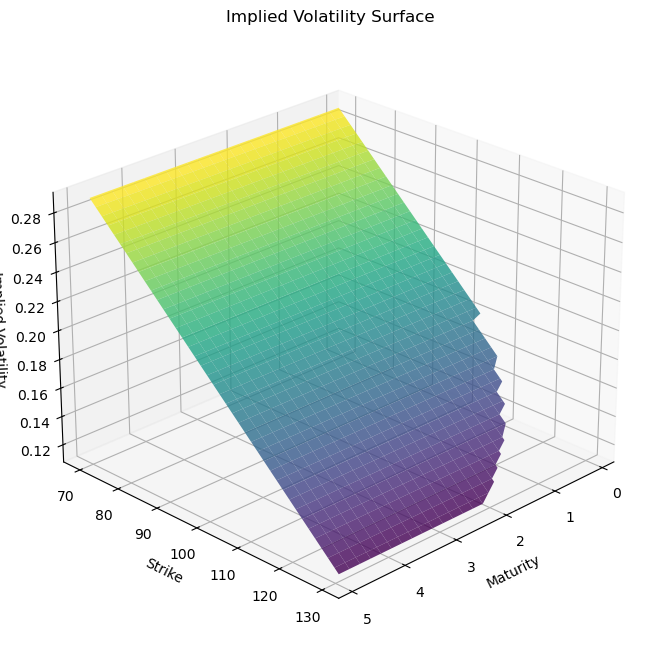

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize
from Option_Contract import OptionContract
from Black_Scholes import bs_price


sp = float(input("Spot : "))
sig = float(input("Volatility : "))
skew = float(input("Skew : "))
rf = float(input("Risk Free Rate : "))
dvd = float(input("Dividends : "))

strike_vect = np.arange(70,130,0.5)
maturity_vect = np.arange(0.1,5,0.2)
data = [(s,m,bs_price(OptionContract(opt_type="call", obs_type="european", spot=sp, strike=s, sigma=sig + skew* (sp - s)/sp , \
                                      maturity=m, risk_free=rf, div=dvd))) for s in strike_vect for m in maturity_vect]
df = pd.DataFrame(data, columns = ["strike", "maturity", "price"])
df = df[df["price"]>=0.005*sp]

def implied_vol(market_price, strike, maturity):
    def recherche(sigma):
        option = OptionContract(opt_type="call", obs_type="european", 
                                spot=sp, strike=strike, sigma=sigma, 
                                maturity=maturity, risk_free=rf, div=dvd)
        return bs_price(option) - market_price
    return scipy.optimize.brentq(recherche, 0.001,5)
df ["implied_volatility"] = df.apply(lambda row : implied_vol(row["price"], row["strike"], row["maturity"]), axis = 1)

pivot = df.pivot_table(values="implied_volatility", index = "strike", columns = "maturity")
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection = "3d")
X,Y = np.meshgrid(pivot.columns, pivot.index)
Z = pivot.values
ax.plot_surface(X, Y, Z, cmap="viridis", alpha = 0.8)
ax.set_xlabel("Maturity")
ax.set_ylabel("Strike")
ax.set_zlabel("Implied Volatility")
ax.set_title("Implied Volatility Surface")
ax.view_init(elev=25, azim=45)
plt.show()